In [1]:
import sys
sys.path.append("..")

In [2]:
import cupy
_ = cupy.cuda.get_local_runtime_version()
sain_runtime = cupy.cuda.runtime

import torch
_ = torch.cuda.is_available()

cupy.cuda.runtime = sain_runtime

from src.sampling import (
    sample_gb_parameters_sobol,
    sample_gb_parameters_lhs,
    sample_gb_parameters_uniform
)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

Dataset will be saved to: data/synthetic_smalltest_gb_dataset as dataset.hdf5


In [3]:
n_samples = 131_072
params_sobol, actual_samples_sobol, N_final_sobol = sample_gb_parameters_sobol(n_samples, seed=42)
params_lhs, nb_samples_lhs, N_final_lhs = sample_gb_parameters_lhs(n_samples, seed=42)
params_uniform, actual_samples_uniform, N_final_uniform = sample_gb_parameters_uniform(n_samples, seed=42)

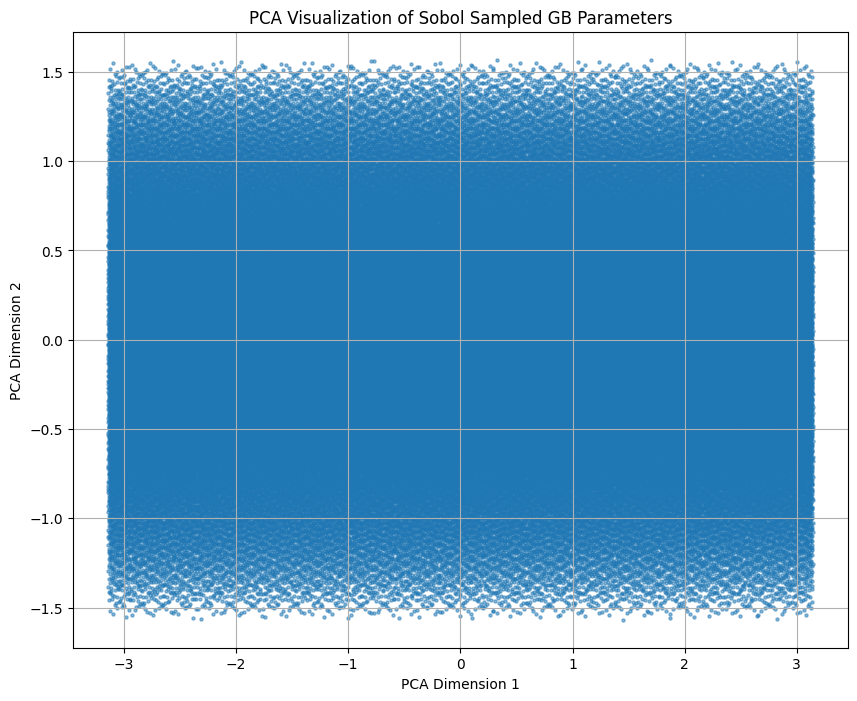

In [4]:
pca_sobol = PCA(n_components=2, random_state=42)
params_2d = pca_sobol.fit_transform(params_sobol.T)
plt.figure(figsize=(10, 8))
plt.scatter(params_2d[:, 0], params_2d[:, 1], s=5, alpha=0.5)
plt.title("PCA Visualization of Sobol Sampled GB Parameters")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.grid()
plt.show()

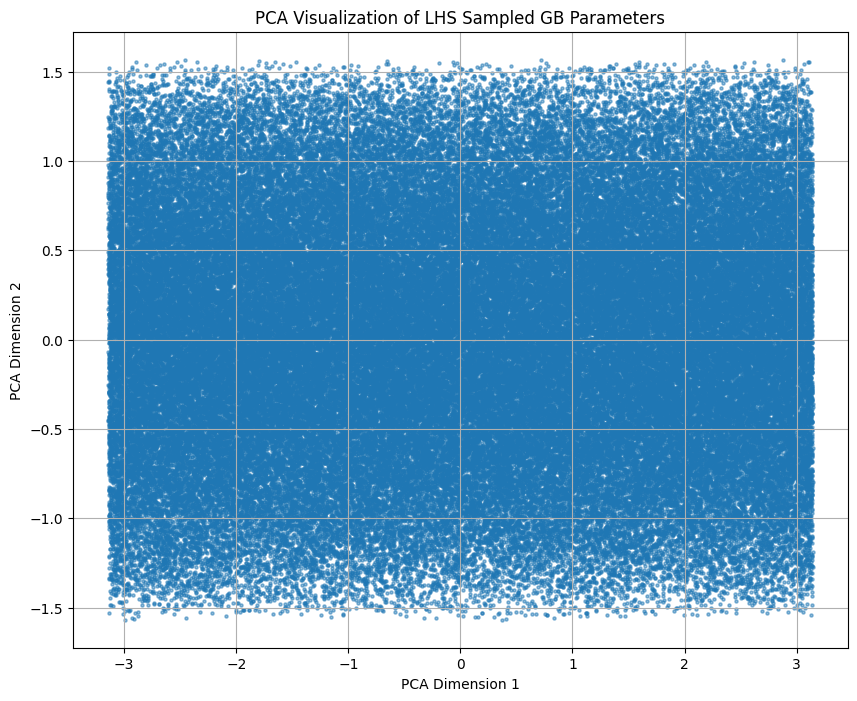

In [5]:
pca_lhs = PCA(n_components=2, random_state=42)
params_lhs, nb_samples_lhs, N_final_lhs = sample_gb_parameters_lhs(n_samples, seed=42)
params_lhs_2d = pca_lhs.fit_transform(params_lhs.T)
plt.figure(figsize=(10, 8))
plt.scatter(params_lhs_2d[:, 0], params_lhs_2d[:, 1], s=5, alpha=0.5)
plt.title("PCA Visualization of LHS Sampled GB Parameters")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.grid()
plt.show()

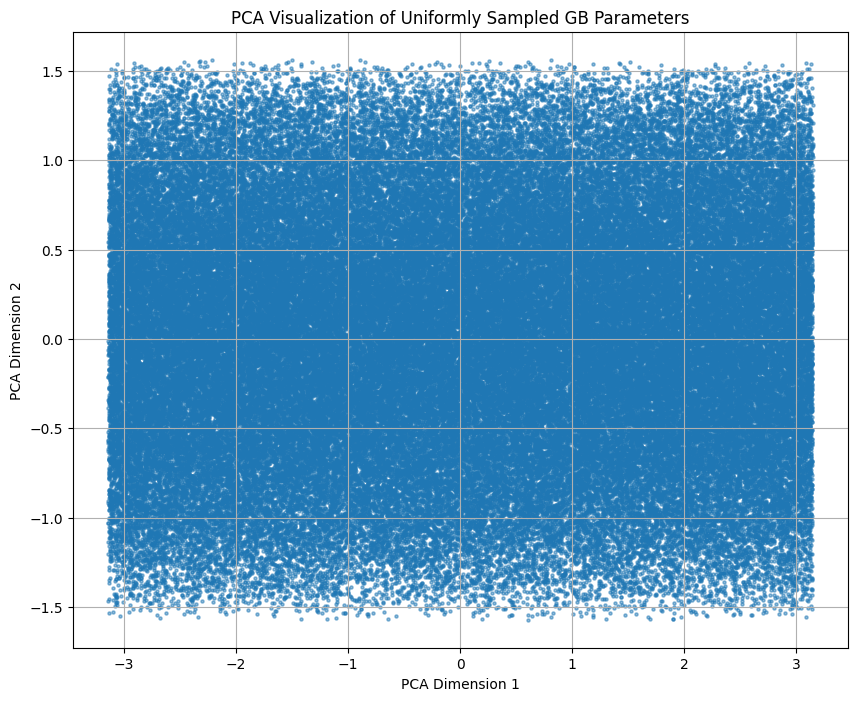

In [6]:
pca_uniform = PCA(n_components=2, random_state=42)
params_uniform_2d = pca_uniform.fit_transform(params_uniform.T)
plt.figure(figsize=(10, 8))
plt.scatter(params_uniform_2d[:, 0], params_uniform_2d[:, 1], s=5, alpha=0.5)
plt.title("PCA Visualization of Uniformly Sampled GB Parameters")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.grid()
plt.show()